In [2]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

file_name= 'ml_python_labexam_2023_02_03.csv'
random_state = 42
np.random.seed(random_state)
df=pd.read_csv(file_name)
df.head()


,X00,X01,X02,X03,X04,X05,X06,X07,X08,X09,y
0,-0.016771,-0.026036,-0.001474,0.104545,0.352163,0.023372,0.003706,0.004963,-0.007113,0.022166,3.288439
1,-0.011618,0.025699,-0.026818,0.053014,0.613195,-0.012447,0.029382,-0.006348,-0.036920,-0.016464,-2.333510
2,0.027478,0.009282,-0.020700,0.630085,0.612415,-0.004157,0.008240,0.019062,0.010821,-0.012983,2.259783
3,-0.003170,-0.001697,-0.028924,0.389900,0.000182,0.027526,0.012792,-0.021192,-0.011102,0.015352,2.939127
4,-0.039508,-0.009104,0.021215,0.951426,0.778600,0.018246,-0.000294,-0.012900,0.004178,0.014846,1.623948


### explore df showing size, data descriptions, data distributions with boxplot, and correlation between columns

In [3]:
df.shape

(1000, 11)

In [4]:
df.describe()

,X00,X01,X02,X03,X04,X05,X06,X07,X08,X09,y
count,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.000127,0.000297,-0.000421,3.378287e-01,2.521912e-01,0.000364,-0.000191,0.000553,0.000130,0.000524,0.437747
std,0.023475,0.018878,0.019124,2.952473e-01,2.877240e-01,0.017402,0.019349,0.017783,0.018999,0.025391,2.407762
min,-0.074550,-0.055749,-0.063489,9.531015e-07,6.913766e-10,-0.054694,-0.058531,-0.054578,-0.062925,-0.073059,-6.609545
25%,-0.015763,-0.012357,-0.013722,6.778294e-02,1.552023e-02,-0.011251,-0.013393,-0.011797,-0.012001,-0.018202,-1.200759
50%,0.000446,0.000269,-0.000891,2.638645e-01,1.218160e-01,0.000675,-0.000333,0.000422,-0.000858,-0.000219,0.336424
75%,0.015529,0.013924,0.012571,5.712697e-01,4.295876e-01,0.012217,0.012797,0.012697,0.012722,0.018642,2.175038
max,0.079599,0.073114,0.052593,9.996939e-01,9.988956e-01,0.053673,0.051803,0.049480,0.061867,0.081461,7.915506


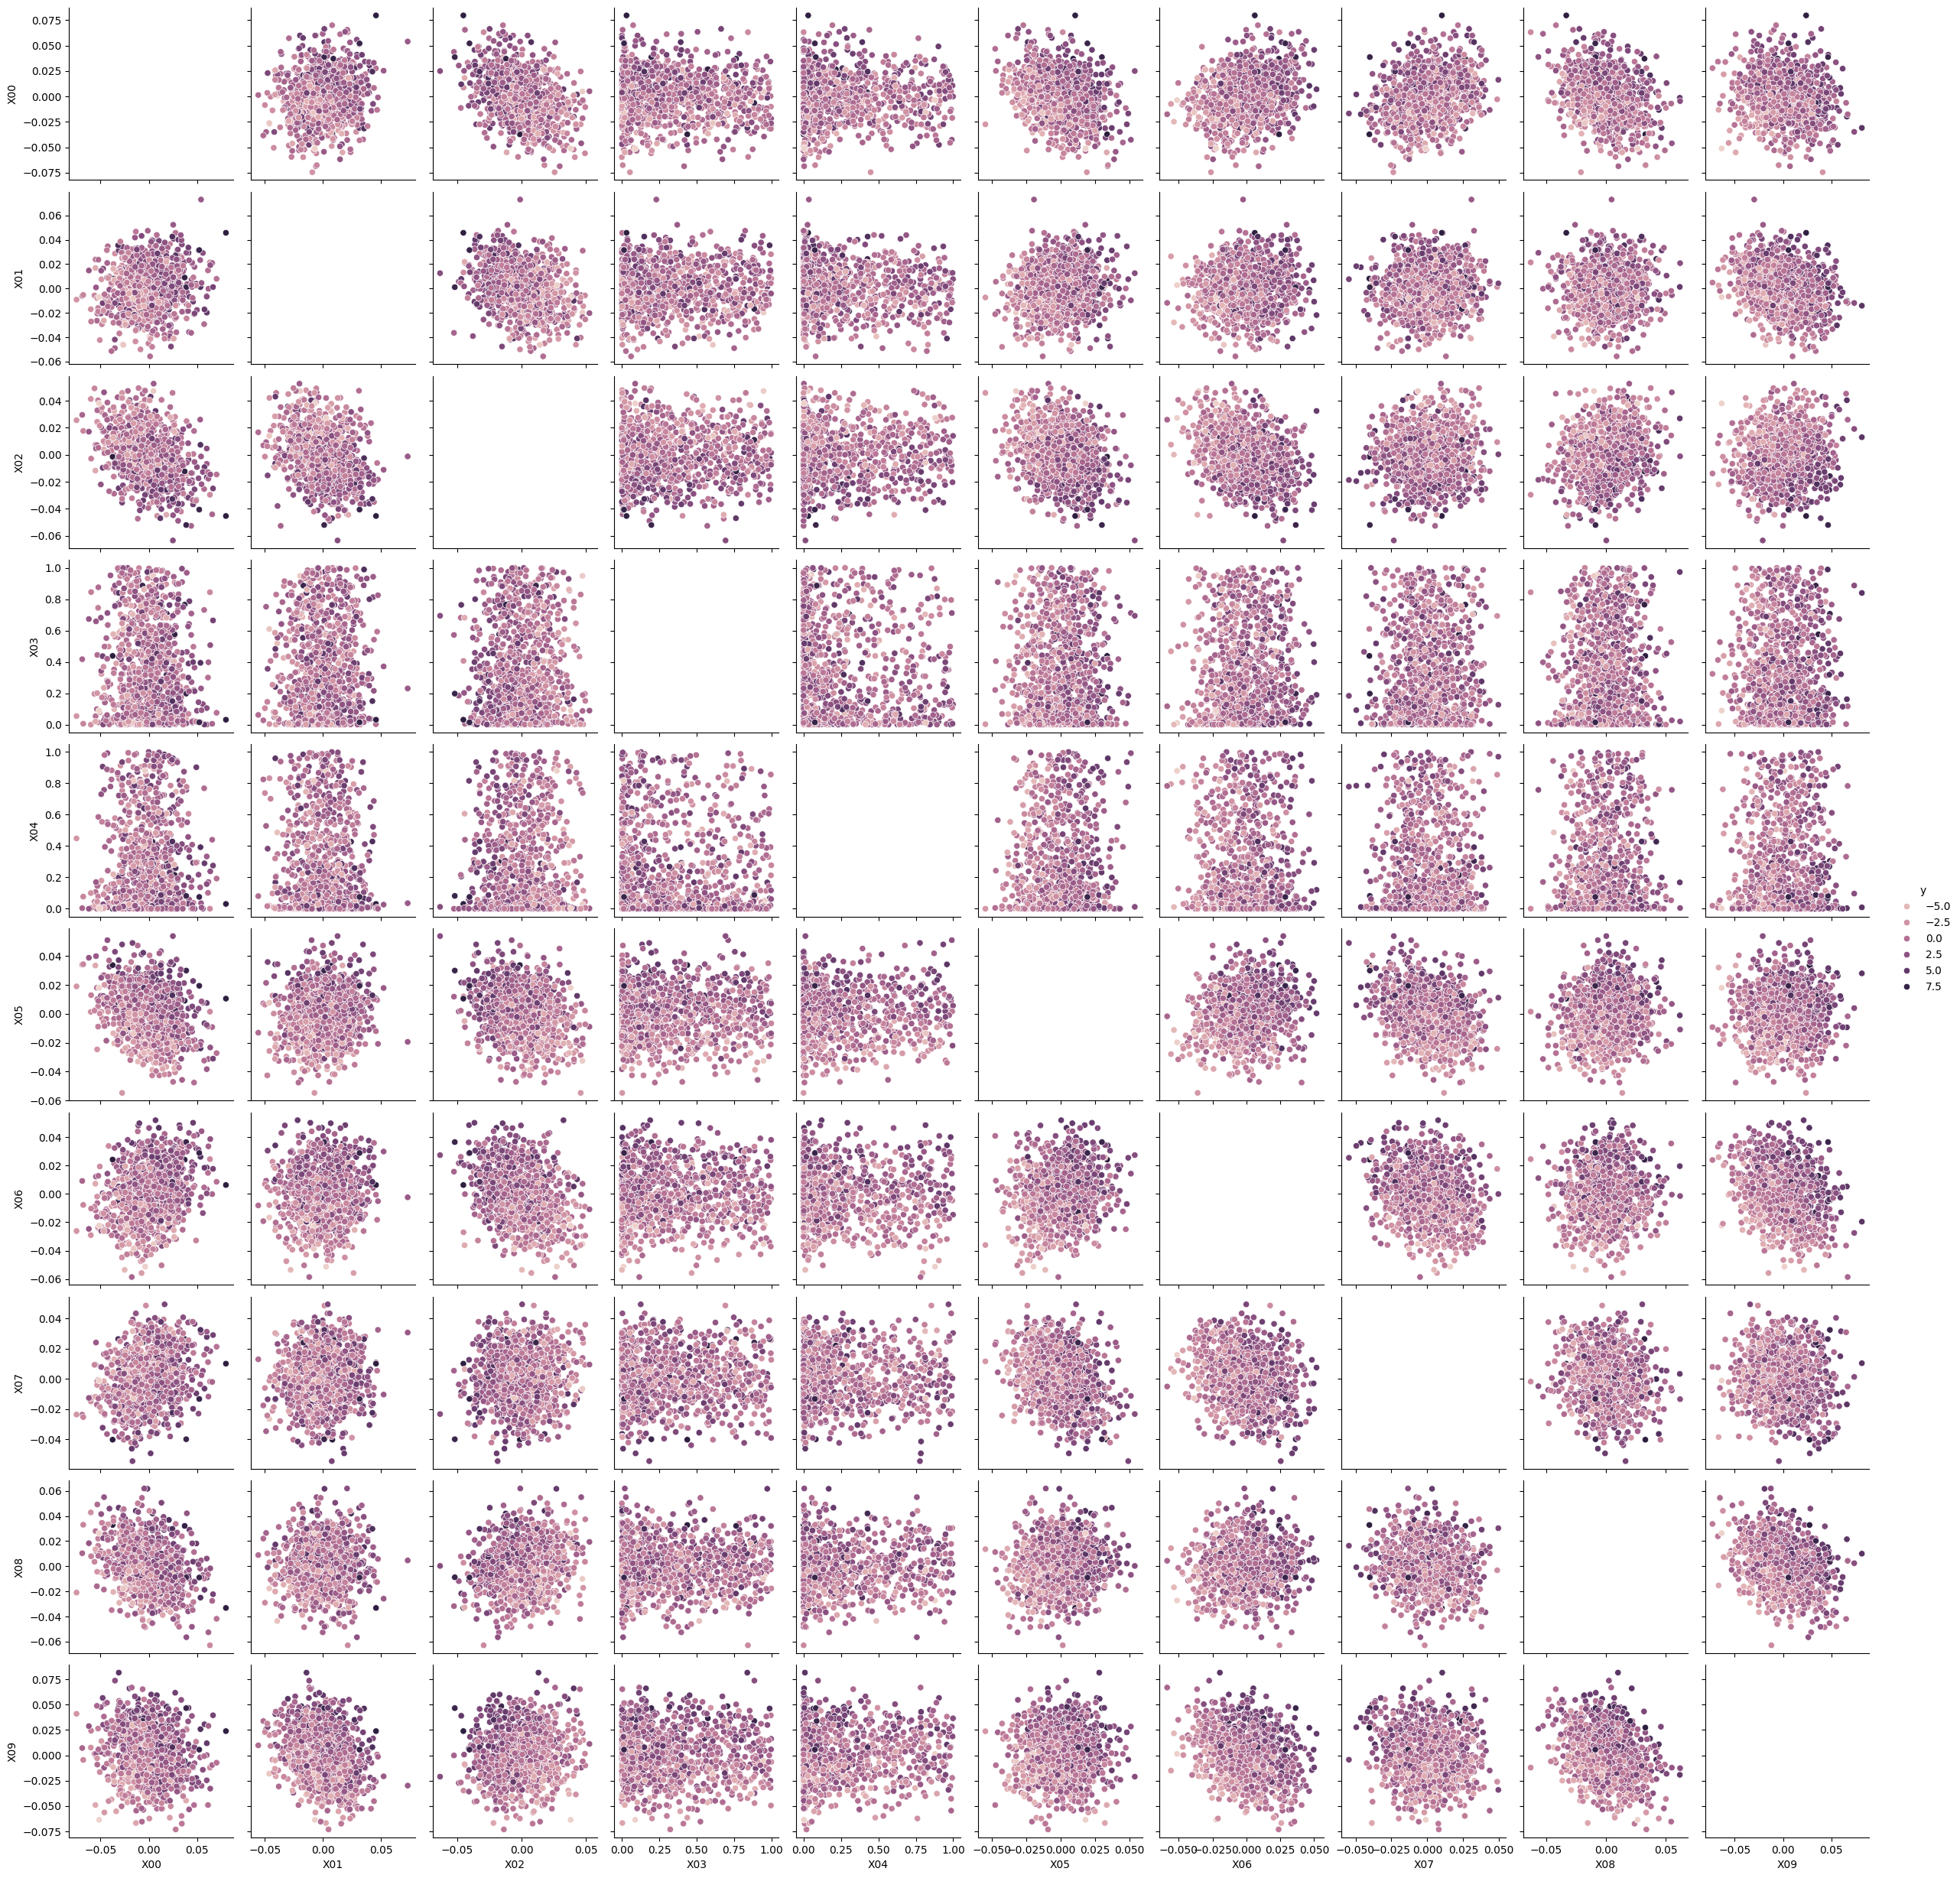

In [6]:
sns.pairplot(df, hue='y')

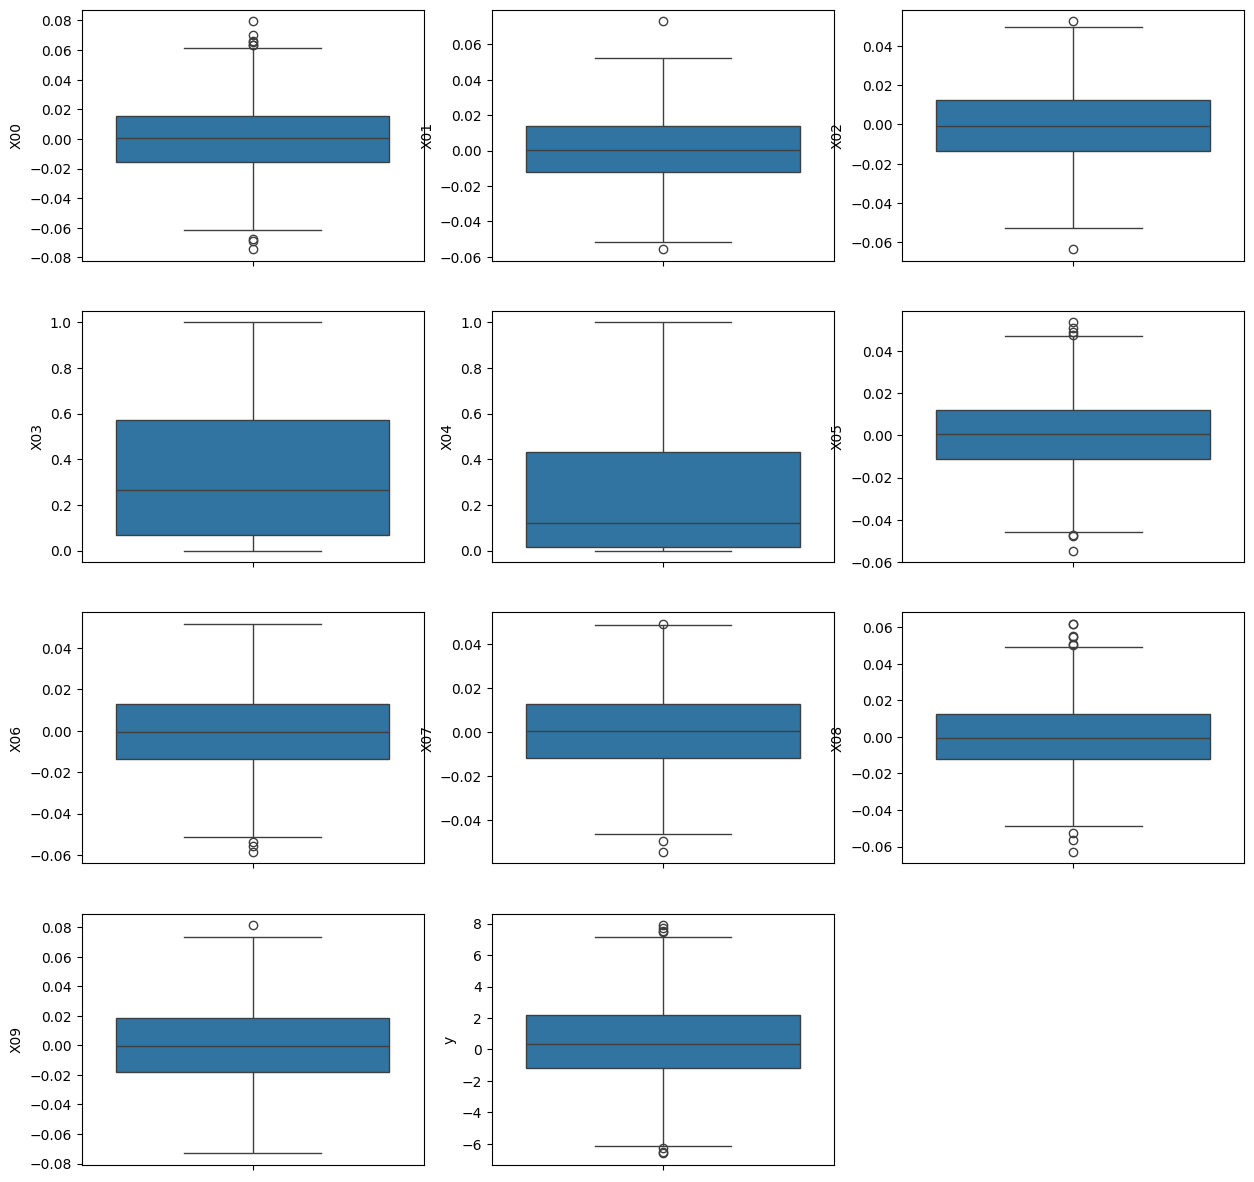

In [7]:
plt.figure(figsize=(15,15))
pos = 1
for i in df.columns:
        if(type(df[i][0]) != str):
                plt.subplot(4, 3, pos)
                sns.boxplot(df[i])
                pos += 1

<Axes: >

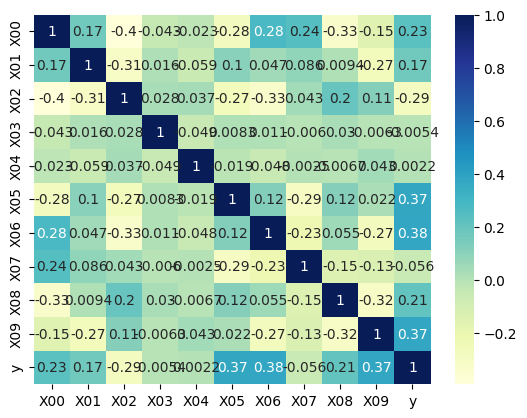

In [8]:

correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap="YlGnBu", annot=True)

In [10]:
correlation_matrix

,X00,X01,X02,X03,X04,X05,X06,X07,X08,X09,y
X00,1.000000,0.170854,-0.395194,-0.043222,-0.023247,-0.275844,0.280314,0.243400,-0.325324,-0.153477,0.227594
X01,0.170854,1.000000,-0.308342,0.015840,-0.059226,0.102338,0.047167,0.086368,0.009363,-0.268953,0.170725
X02,-0.395194,-0.308342,1.000000,0.028499,0.036766,-0.266042,-0.326706,0.043103,0.195065,0.112824,-0.287004
X03,-0.043222,0.015840,0.028499,1.000000,-0.049209,0.008271,0.011157,-0.006028,0.029519,-0.006292,-0.005415
X04,-0.023247,-0.059226,0.036766,-0.049209,1.000000,-0.018662,-0.048011,-0.002504,-0.006653,0.042886,0.002213
X05,-0.275844,0.102338,-0.266042,0.008271,-0.018662,1.000000,0.119608,-0.292621,0.115454,0.021566,0.369986
X06,0.280314,0.047167,-0.326706,0.011157,-0.048011,0.119608,1.000000,-0.228867,0.054893,-0.274311,0.376340
X07,0.243400,0.086368,0.043103,-0.006028,-0.002504,-0.292621,-0.228867,1.000000,-0.145627,-0.132451,-0.056175
X08,-0.325324,0.009363,0.195065,0.029519,-0.006653,0.115454,0.054893,-0.145627,1.000000,-0.316079,0.209655
X09,-0.153477,-0.268953,0.112824,-0.006292,0.042886,0.021566,-0.274311,-0.132451,-0.316079,1.000000,0.374650


### Comment the exploration of step 1 pointing out if there are predicting columns having the absolute value of correlation with the target less than 0.15

COLUMNS with less than 0.15 corr with y absoute value are: X03, X04, X07

### train test a multivariate linear regressor and show the Root Mean Squared Error

In [13]:
X=df.drop('y', axis=1)
y=df['y']



0    3.288439
1   -2.333510
2    2.259783
3    2.939127
4    1.623948
Name: y, dtype: float64

In [26]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y,train_size = 0.7, random_state = random_state)
print(f"We have {Xtrain.shape[0]} items in our training set")
print(f"We have {Xtest.shape[0]} items in our test set")


We have 700 items in our training set
We have 300 items in our test set


In [27]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

reg=linear_model.LinearRegression()
reg.fit(Xtrain,ytrain)
ypred=reg.predict(Xtest)

rmse_dt = mean_squared_error(ytest, ypred)
print("Linear Regression - RMSE = {:.2f}".format(rmse_dt))

Linear Regression - RMSE = 0.77


### train test a multivariate linear regressor on the reduced dataset obtained dropping the columns loosely correlated with the target, and show the Root Mean Squared Error

In [30]:
dfclean=df.drop(['X03', 'X04', 'X07'], axis =1)


In [32]:
X=dfclean.drop('y', axis=1)
y=dfclean['y']
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y,train_size = 0.7, random_state = random_state)
print(f"We have {Xtrain.shape[0]} items in our training set")
print(f"We have {Xtest.shape[0]} items in our test set")

reg=linear_model.LinearRegression()
reg.fit(Xtrain,ytrain)
ypred=reg.predict(Xtest)

rmse_dt = mean_squared_error(ytest, ypred)
print("Linear Regression - RMSE = {:.2f}".format(rmse_dt))
    

We have 700 items in our training set
We have 300 items in our test set
Linear Regression - RMSE = 0.97


### train and test on the reduced dataset a decision tree regressor, and show the Root Mean Squared Error

In [43]:
from sklearn.tree import DecisionTreeRegressor

dtr=DecisionTreeRegressor(random_state=random_state)
dtr.fit(Xtrain,ytrain)

ydtr=dtr.predict(Xtest)
print(f"DT max Depth= {dtr.tree_.max_depth}")

rmse_dt = mean_squared_error(ytest, ydtr)
print("DT Regression - RMSE = {:.2f}".format(rmse_dt))


DT max Depth= 20
DT Regression - RMSE = 4.20


### optimise the depth of the decision tree regressor of step 5 searching for the minimum Root Mean Squared Error with cross-validation, and show the best RMSE

In [47]:
from sklearn.model_selection import GridSearchCV
param_grid = {'max_depth': list(range(1,dtr.tree_.max_depth))}
# create the grid search cross validation object
dt_gscv = GridSearchCV(estimator=DecisionTreeRegressor(random_state=random_state)
                    , param_grid=param_grid
                    , scoring='neg_mean_squared_error' # select model with minimum mse
                    )
dt_gscv.fit(Xtrain,ytrain);
dt_best = dt_gscv.best_estimator_ # the GridSearchCV returns the best estimator
best_max_depth = dt_best.tree_.max_depth
print("The optimal maximum depth for the decision tree is {}".format(best_max_depth))

The optimal maximum depth for the decision tree is 7


In [48]:
ybest=dt_best.predict(Xtest)

rmse_dt = mean_squared_error(ytest, ybest)
print("DT Regression - RMSE = {:.2f}".format(rmse_dt))

DT Regression - RMSE = 4.10
